# Part I · Block 2 — Parameter Sensitivity
**Tasks 3, 4, 5** | *Worksheet §Part I, Block 2 (30 min)*

Keeping the same block (Exp 1, Site 1, ERK), re-run the script with different values of
$r$ (spatial radius), $W$ (future window), and $q$ (jump quantile).  
Fill in each results table, then answer the interpretation questions.

In [1]:
import sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

EXP_ID     = 1
SITE_ID    = 1
SIGNAL_COL = 'ERKKTR_ratio'

def run_block(exp, site, signal, radius, window, quantile, threshold=None):
    """Run the single-block script and return the parsed summary dict."""
    tag   = f'exp_{exp}_site_{site}_{signal}_r{radius}_w{window}_q{int(quantile*100)}'
    outdir = OUTPUT_ROOT / tag
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path',            str(DATA_PATH),
        '--meta-path',            str(META_PATH),
        '--exp-id',               str(exp),
        '--site-id',              str(site),
        '--signal-col',           signal,
        '--spatial-radius',       str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile',        str(quantile),
        '--output-dir',           str(outdir.parent),
    ]
    if threshold is not None:
        cmd += ['--jump-threshold', str(threshold)]
    subprocess.run(cmd, capture_output=True)
    summary_path = outdir / 'summary.json'
    if not summary_path.exists():
        # fallback: script may have used default output naming
        summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    with open(summary_path) as f:
        return json.load(f)

print('Setup complete.')

Setup complete.


> **Note:** each script run reads the full CSV file, so the loop cells below may take
> a few minutes. Run them once and then work with the resulting DataFrames.

---
## Task 3 — Varying the spatial radius $r$

We fix $W = 3$, $q = 0.90$ and vary $r \in \{30, 60, 90, 150\}$.

In [7]:
radii = [30, 60, 90, 150]
rows_r = []
for r in radii:
    print(f'  running r={r} …', end=' ', flush=True)
    # Re-use standard output dir for r=60 (already computed in Block 1)
    if r == 60:
        outpath = OUTPUT_ROOT / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
        with open(outpath) as f:
            s = json.load(f)
    else:
        outdir = OUTPUT_ROOT / f'sweep_r{r}'
        cmd = [
            sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
            '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
            '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
            '--signal-col', SIGNAL_COL,
            '--spatial-radius', str(r),
            '--future-window-frames', '3',
            '--jump-quantile', '0.9',
            '--output-dir', str(outdir),
        ]
        subprocess.run(cmd, capture_output=True)
        sp = next((outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}').glob('summary.json'), None)
        if sp is None:
            sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
        with open(sp) as f:
            s = json.load(f)
    rows_r.append({
        'r': r,
        '|E_sp|': s['n_spatial_edges'],
        'θ': round(s['jump_threshold'], 4),
        'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
        'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
        'RR': round(s['relative_risk'], 4),
        'RD': round(s['risk_difference'], 4),
    })
    print('done')

df_r = pd.DataFrame(rows_r).set_index('r')
df_r

  running r=30 … done
  running r=60 … done
  running r=90 … done
  running r=150 … done


,|E_sp|,θ,p_exp,p_unexp,RR,RD
r,,,,,,
30,508839,0.0365,0.1797,0.0869,2.0680,0.0928
60,2389504,0.0365,0.1315,0.0749,1.7558,0.0566
90,5401402,0.0365,0.1120,0.0698,1.6051,0.0422
150,14339412,0.0365,0.0998,0.0751,1.3281,0.0247


### Task 3(a) — Does $|E_\mathrm{sp}|$ scale as $r^2$?

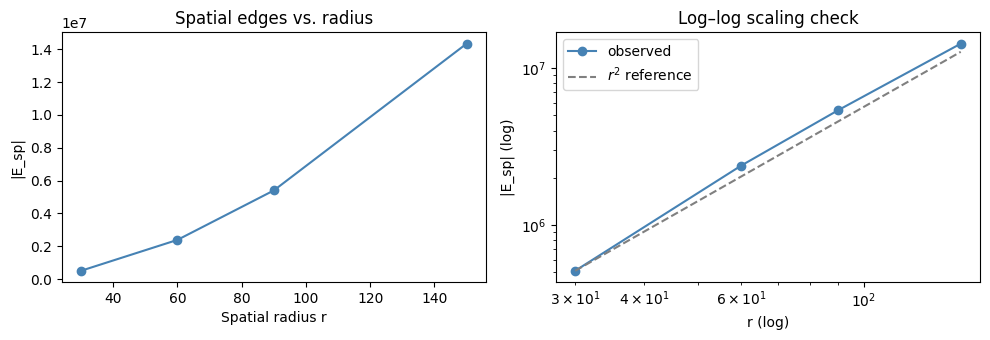

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Left: |E_sp| vs r
axes[0].plot(df_r.index, df_r['|E_sp|'], 'o-', color='steelblue')
axes[0].set_xlabel('Spatial radius r')
axes[0].set_ylabel('|E_sp|')
axes[0].set_title('Spatial edges vs. radius')

# Right: log-log plot to check power-law scaling
axes[1].loglog(df_r.index, df_r['|E_sp|'], 'o-', color='steelblue', label='observed')
# Reference r^2 line
r_ref = np.array(df_r.index, dtype=float)
scale = df_r['|E_sp|'].iloc[0] / r_ref[0]**2
axes[1].loglog(r_ref, scale * r_ref**2, '--', color='grey', label='$r^2$ reference')
axes[1].set_xlabel('r (log)')
axes[1].set_ylabel('|E_sp| (log)')
axes[1].set_title('Log–log scaling check')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# Does the log-log slope ≈ 2, confirming O(r^2) growth?


### Task 3(b) — How does RR change with $r$?

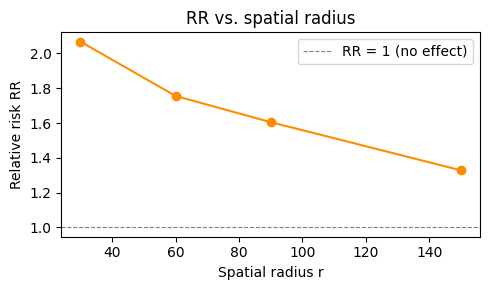

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(df_r.index, df_r['RR'], 'o-', color='darkorange')
ax.axhline(1, color='grey', ls='--', lw=0.8, label='RR = 1 (no effect)')
ax.set_xlabel('Spatial radius r')
ax.set_ylabel('Relative risk RR')
ax.set_title('RR vs. spatial radius')
ax.legend()
plt.tight_layout()
plt.show()

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# Why should RR → 1 as r → ∞?


---
## Task 4 — Varying the future window $W$

Fix $r = 60$, $q = 0.90$; vary $W \in \{1, 3, 6, 12\}$.

In [ ]:
windows = [1, 3, 6, 12]
rows_w = []
for w in windows:
    print(f'  running W={w} …', end=' ', flush=True)
    outdir = OUTPUT_ROOT / f'sweep_w{w}'
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
        '--signal-col', SIGNAL_COL,
        '--spatial-radius', '60',
        '--future-window-frames', str(w),
        '--jump-quantile', '0.9',
        '--output-dir', str(outdir),
    ]
    subprocess.run(cmd, capture_output=True)
    sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
    with open(sp) as f:
        s = json.load(f)
    rows_w.append({
        'W (frames)': w,
        'W (min)': w * 5,
        'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
        'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
        'RR': round(s['relative_risk'], 4),
        'RD': round(s['risk_difference'], 4),
    })
    print('done')

df_w = pd.DataFrame(rows_w).set_index('W (frames)')
df_w

  running W=1 … 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(df_w['W (min)'], df_w['p_exp'],   'o-', label='$p_{\\mathrm{exp}}$')
axes[0].plot(df_w['W (min)'], df_w['p_unexp'], 's--', label='$p_{\\mathrm{unexp}}$')
axes[0].set_xlabel('Future window W (min)')
axes[0].set_ylabel('Future jump rate')
axes[0].set_title('Conditional rates vs. W')
axes[0].legend()

axes[1].plot(df_w['W (min)'], df_w['RR'], 'o-', color='darkorange')
axes[1].axhline(1, color='grey', ls='--', lw=0.8)
axes[1].set_xlabel('Future window W (min)')
axes[1].set_ylabel('RR')
axes[1].set_title('Relative risk vs. W')

plt.tight_layout()
plt.show()

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# (a) Do p_exp and p_unexp both rise with W? Does RR change monotonically?
# (b) At which W does RR peak? What does this suggest about the ERK relay timescale?


---
## Task 5 — Varying the jump quantile $q$

Fix $r = 60$, $W = 3$; vary $q \in \{0.70, 0.80, 0.90, 0.95\}$.

In [ ]:
quantiles = [0.70, 0.80, 0.90, 0.95]
rows_q = []
for q in quantiles:
    print(f'  running q={q} …', end=' ', flush=True)
    outdir = OUTPUT_ROOT / f'sweep_q{int(q*100)}'
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
        '--signal-col', SIGNAL_COL,
        '--spatial-radius', '60',
        '--future-window-frames', '3',
        '--jump-quantile', str(q),
        '--output-dir', str(outdir),
    ]
    subprocess.run(cmd, capture_output=True)
    sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
    with open(sp) as f:
        s = json.load(f)

    # Also load nodes to get the fraction of jump events
    nodes_path = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'nodes.csv.gz'
    nodes_q = pd.read_csv(nodes_path)
    jump_frac = nodes_q['jump_event'].mean()

    rows_q.append({
        'q': q,
        'θ_q': round(s['jump_threshold'], 4),
        '% jump nodes': round(jump_frac * 100, 1),
        'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
        'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
        'RR': round(s['relative_risk'], 4),
    })
    print('done')

df_q = pd.DataFrame(rows_q).set_index('q')
df_q

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(df_q.index, df_q['% jump nodes'], 'o-', color='steelblue')
axes[0].set_xlabel('Quantile q')
axes[0].set_ylabel('% nodes labelled as jumps')
axes[0].set_title('Jump frequency vs. q')

axes[1].plot(df_q.index, df_q['RR'], 'o-', color='darkorange')
axes[1].axhline(1, color='grey', ls='--', lw=0.8)
axes[1].set_xlabel('Quantile q')
axes[1].set_ylabel('RR')
axes[1].set_title('Relative risk vs. q')

plt.tight_layout()
plt.show()

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# (a) How does the jump fraction scale with q?
# (b) Are rarer, larger jumps more or less spatially coordinated?
